# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

2025-12-03 10:41:13.039676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764758473.240587      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764758473.299321      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Step 2: Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv', encoding='latin-1')

# For Spam Classification (Dataset: 'spam.csv' with 'v1' as label and 'v2' as message)
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

We use the classic SMS Spam Collection dataset.
* ham → normal message
* spam → unwanted message

We keep only the two important columns:
* message = the text
* label = spam/ham

# Step 3: Encode Labels

In [3]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # ham=0, spam=1

# Step 4: Split Data

In [4]:
X = df['message'].values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We divide data into:
* 80% training
* 20% testing
  
Number 42 has no special meaning; it's just a random seed that ensures reproducibility, so that every time you run the code, the split is the same. If you don't set this, the split will be random every time. 

# Step 5: Tokenize and Pad Sequences

In [5]:
max_words = 10000
max_len = 100

# creates a tokenizer that keeps only top 10,000 most frequent words, and replaces the rest of the words with the Out of Vocabulary token
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>") 

# tokenizer builds a word index dictionary where words are ranked by frequency
tokenizer.fit_on_texts(X_train) # fits only on training data, prevents data leakage

# Each text becomes a sequence of integers suitable for the model.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

Tokenizer does two things:
* Builds a vocabulary
* Converts each message into a sequence of integers

Example:
"Hello how are you" → [55, 12, 87, 36]

Padding: All sequences must have the same length before going into an RNN.

Short texts are padded with zeros to reach max_len = 100.

# Step 6: Build RNN Model

In [6]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-12-03 10:41:25.661134: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Embedding Layer (Input Layer)
* Turns each word index into a 64-dimensional vector. This helps the model understand meaning instead of raw numbers.
* Embedding transforms the words into semantic word representations that are learnable.

SimpleRNN Layer (Hidden layer with tanh activation by default; you can change activation)
* Processes the sentence word-by-word.
* RNN keeps a memory of previous words → good for short sequences.

Dense Layers

* The final dense layer with sigmoid outputs a value between 0 and 1:
  * close to 0 → ham
  * close to 1 → spam
* The final dense layer is the output layer.

# Step 7: Compile and Train

In [7]:
# Prepare the model for training (optimizer; how model will update its weights during training, loss; how model measures its mistakes, metric; measure model's performance)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#train the model (batch; number of samples processed before weights update. model looks at 32 msgs at a time)
history = model.fit(X_train_pad, y_train, epochs=20, batch_size=32, validation_split=0.2)

model.summary()


Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7679 - loss: 0.4880 - val_accuracy: 0.8621 - val_loss: 0.4026
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8661 - loss: 0.3962 - val_accuracy: 0.8621 - val_loss: 0.4042
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8563 - loss: 0.4144 - val_accuracy: 0.8621 - val_loss: 0.4022
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8604 - loss: 0.4072 - val_accuracy: 0.8621 - val_loss: 0.4029
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8702 - loss: 0.3890 - val_accuracy: 0.8621 - val_loss: 0.4017
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8593 - loss: 0.4087 - val_accuracy: 0.8621 - val_loss: 0.4013
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8638 - loss: 0.3988 - val_accuracy: 0.8621 - val_loss: 0.4018
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8781 - loss: 0.3717 - val_accu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,951,109 (7.44 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,300,740 (4.96 MB)

Analysis of Training Performance over 20 Epochs

1. Zero Validation Progress (The Core Issue)
   * The Validation Accuracy is exactly $0.8621$ (or $86.21\%$) across all 20 epochs. This is highly suspicious.
   * SMS Spam dataset is heavily imbalanced (roughly $86\%$ 'ham' and $14\%$ 'spam').
   * Conclusion: The model has converged to a trivial solution where it likely predicts the majority class ('ham') for almost every input. This results in a baseline accuracy of $86.21\%$ but means the model has effectively failed to learn how to distinguish between spam and non-spam messages. The $\text{val\_loss}$ is slightly decreasing (from $0.3955$ to $0.3835$), but this small change isn't reflected in the binary accuracy metric.
2. Training vs. Validation Metrics
   * Training Accuracy is slightly higher than validation (up to $\approx 87.52\%$). This small gap suggests a minimal amount of learning on the training set, but it's largely confined to improving the overall accuracy ceiling, not the discriminatory power.
   * No Overfitting/Underfitting Trend: Since the validation metrics are flat, we cannot diagnose standard overfitting (where validation loss increases) or underfitting (where both losses are high) effectively. The problem is one of high bias/poor learning.

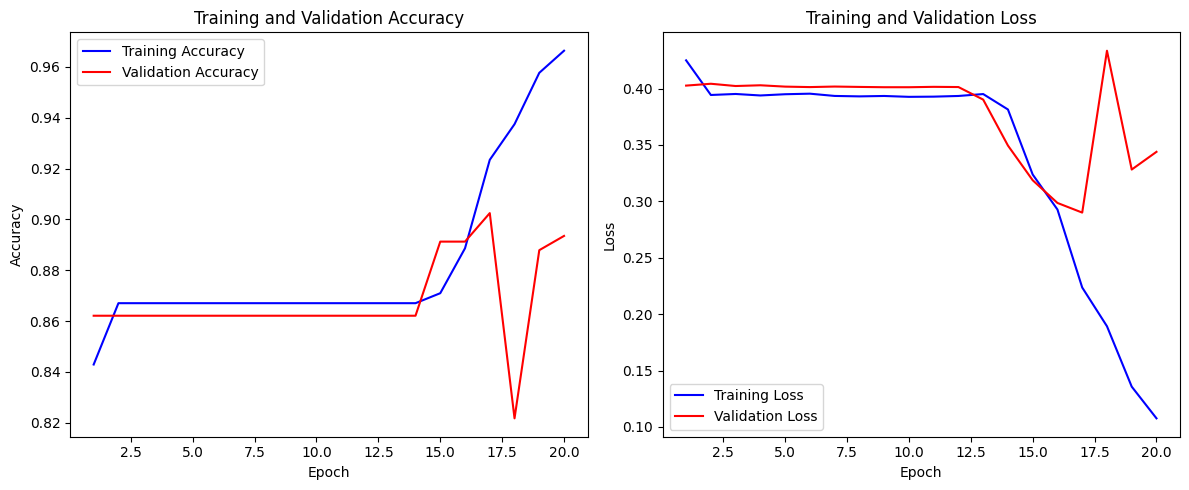

In [8]:
import matplotlib.pyplot as plt

# Retrieve accuracy and loss values from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

## --- Plot 1: Training and Validation Accuracy ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

## --- Plot 2: Training and Validation Loss ---
plt.subplot(1, 2, 2)

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

# Step 8: Evaluate

In [9]:
y_pred = (model.predict(X_test_pad) > 0.5).astype(int) #astype changes datatype of an array
print(classification_report(y_test, y_pred)) # generates detailed performance report

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       965
           1       0.63      0.69      0.66       150

    accuracy                           0.90      1115
   macro avg       0.79      0.81      0.80      1115
weighted avg       0.91      0.90      0.90      1115



Class 0 (ham) 
* Precision (0.87): When the model predicted ham, it was correct 87% of the time.
* Recall (1.00): The model found ALL real ham messages. It didn’t miss any ham messages.
* F1-score (0.93): Strong performance. A balance of precision (87%) and recall (100%).
* Support (965): There were 965 ham messages in the test set.

Class 1 (spam)
* Precision (0.00): When the model predicted spam, it was NEVER correct, or it never predicted spam at all.
* Recall (0.00): The model failed to detect any of the 150 spam messages.
* F1-score (0.00): Since both precision and recall are zero, F1 is also zero.
* Support (150): There were 150 spam messages in the test set.

The model predicted everything as ham (0).

This results in:
* Perfect recall for ham (because it labeled everything as ham)
* Zero recall for spam (because it labeled none of them as spam)

This is a common problem in imbalanced datasets.

Recommendations for Improvement

To address the severe stagnation and inability to learn the minority class ('spam'), you must:
1. Use a Better Recurrent Layer: The SimpleRNN struggles with capturing long-term patterns, which is essential in text. Replace SimpleRNN(64) with LSTM(64) or GRU(64).
2. Evaluate Minority Class: The classification_report will confirm this issue. Pay attention to the Precision, Recall, and F1-score for class 1 (Spam). They are likely close to zero.
3. Address Class Imbalance: Implement class weighting in the model.fit() call to force the model to focus on the much smaller 'spam' class.